# Предсказание исхода партии

## Задача

Признаки до начала игры:

- Разница рейтингов
- Цвет фигур

Признаки в некоторый момент игры:

- Номер хода
- Мои фигуры на доске
- Преимущество по фигурам
- Оставшееся у меня время
- Преимущество по времени

| Модель          | Роль       | Преимущества                           |
|-----------------|------------|----------------------------------------|
| Lin. Regression | Baseline   | Простая, легко интерпретировать        |
| \* Boosting     | Prediction | Нелинейности, взаимодействия признаков |

## Подготовка окружения

```bash
./tools/install.sh
source .venv/bin/activate
python tools/get_data.py
```

In [1]:
import pandas as pd

import chess
import chess.pgn

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
from   datetime import datetime

## Подготовка данных

### Рассмотрим какую-нибудь игру

In [2]:
def get_game(path: str, index: int) -> str:
    with open(path) as f:
        for _ in range(index):
            chess.pgn.skip_game(f)
        return chess.pgn.read_game(f)

In [3]:
print(get_game("data.pgn", 0))

[Event "rated blitz game"]
[Site "https://lichess.org/Lnhx4IvX"]
[Date "2026.04.29"]
[Round "-"]
[White "qorovin"]
[Black "crazyhandrick"]
[Result "0-1"]
[GameId "Lnhx4IvX"]
[UTCDate "2026.04.29"]
[UTCTime "12:58:46"]
[WhiteElo "1309"]
[BlackElo "1297"]
[WhiteRatingDiff "-6"]
[BlackRatingDiff "+6"]
[Variant "Standard"]
[TimeControl "300+3"]
[ECO "C44"]
[Opening "Ponziani Opening"]
[Termination "Time forfeit"]

1. e4 { [%clk 0:05:00] } 1... e5 { [%clk 0:05:00] } 2. Nf3 { [%clk 0:05:02] } 2... Nc6 { [%clk 0:05:00] } 3. c3 { [%clk 0:05:05] } 3... d6 { [%clk 0:05:01] } 4. d4 { [%clk 0:05:00] } 4... Bg4 { [%clk 0:05:02] } 5. d5 { [%clk 0:04:59] } 5... Bxf3 { [%clk 0:05:04] } 6. Qxf3 { [%clk 0:04:57] } 6... Nce7 { [%clk 0:05:00] } 7. Bb5+ { [%clk 0:04:54] } 7... c6 { [%clk 0:05:01] } 8. dxc6 { [%clk 0:04:50] } 8... bxc6 { [%clk 0:05:02] } 9. Bc4 { [%clk 0:04:46] } 9... Nf6 { [%clk 0:05:00] } 10. Bg5 { [%clk 0:04:36] } 10... Ng6 { [%clk 0:04:58] } 11. Bxf6 { [%clk 0:04:30] } 11... gxf6 { [%cl

### Какие данные потребуются

| Признаки                | Изменения                                                |
|-------------------------|----------------------------------------------------------|
| `Variant`               |    Оставить только `"Variant = Standard"`                |
| `WhiteElo` + `BlackElo` | -> `rate_d` (мой рейтинг минус соперника)                |
| `White` + `Black`       | -> `color` (цвет моих фигур)                             |
| `Запись ходов`          | -> `moves [ (sec=300, sec_d=0, mat=39, mat_d=0) , ... ]` |
| `Result`                | -> `win / draw / loss` (one-hot)                         |

### `df`

In [4]:
NICK     = "qorovin"
SEC_INIT = 300

PIECE_VALUES = {
    chess.PAWN:   1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK:   5,
    chess.QUEEN:  9,
}

In [5]:
def parse_clock(comment):

    m = re.search(r'\[%clk 0:(\d+):(\d+)\]', comment)
    return int(m.group(1)) * 60 + int(m.group(2)) if m else None

In [6]:
def count_material(board, color):
    return sum(len(board.pieces(pt, color)) * val for pt, val in PIECE_VALUES.items())

def material_advantage(board, my_color):
    return count_material(board, my_color) - count_material(board, not my_color)

In [7]:
def parse_moves(game, my_color):

    opp_color = not my_color

    moves  = []
    clocks = {chess.WHITE: SEC_INIT, chess.BLACK: SEC_INIT}

    # game — корневой узел (позиция до первого хода)
    node = game

    while node.variations:
        # variations[0] — следующий ход основной линии
        node = node.variations[0]

        # parent.board() — позиция ДО этого хода
        # .turn          — кто сделал текущий ход
        mover = node.parent.board().turn
        clk   = parse_clock(node.comment)

        if clk is not None:
            if mover == my_color:
                # node.board() — позиция ПОСЛЕ моего хода
                board = node.board()
                mat   = count_material(board, my_color)
                mat_d = material_advantage(board, my_color)
                moves.append((clk, clk - clocks[opp_color], mat, mat_d))
            clocks[mover] = clk

    return moves

In [8]:
rows = []

with open("data.pgn") as f:
    while True:
        game = chess.pgn.read_game(f)
        if game is None: break

        headers = game.headers
        if headers.get("Variant", "Standard") != "Standard": continue

        is_white = (headers["White"] == NICK)
        my_color = chess.WHITE if is_white else chess.BLACK

        result = headers["Result"]
        if result == "1/2-1/2":
            win, draw, loss = 0, 1, 0
        elif (result == "1-0") == is_white:
            win, draw, loss = 1, 0, 0
        else:
            win, draw, loss = 0, 0, 1

        rate_d = (int(headers["WhiteElo"]) - int(headers["BlackElo"])) * (1 if is_white else -1)

        rows.append({
            "date":      datetime.strptime(headers["UTCDate"], "%Y.%m.%d").toordinal(),
            "color":     int(is_white),
            "rate_d":    rate_d,
            "win":       win,
            "draw":      draw,
            "loss":      loss,
            "moves":     parse_moves(game, my_color)
        })

df = pd.DataFrame(rows)

date = df["date"]
df["date"] = (date - date.min()) / (date.max() - date.min())

df.shape

(2052, 7)

In [9]:
pd.concat([df.head(3), df.tail(3)])

,date,color,rate_d,win,draw,loss,moves
0,1.000000,1,12,0,0,1,"[(300, 0, 39, 0), (302, 2, 39, 0), (305, 5, 39..."
1,0.998870,0,-13,0,1,0,"[(300, 0, 39, 0), (301, 0, 39, 0), (301, 2, 39..."
2,0.997740,1,23,0,0,1,"[(300, 0, 39, 0), (302, 2, 39, 1), (293, -8, 3..."
2049,0.030508,0,-32,1,0,0,"[(300, 0, 39, 0), (291, 11, 39, 0), (291, 15, ..."
2050,0.030508,1,-16,0,0,1,"[(300, 0, 39, 0), (296, -4, 39, 0), (288, -8, ..."
2051,0.000000,0,-21,0,0,1,"[(300, 0, 39, 0), (301, 1, 39, 0), (301, 0, 39..."


## EDA

#### corr_mat

<Axes: >

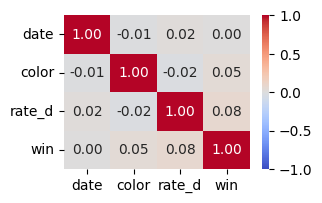

In [10]:
features = ["date", "color", "rate_d", "win"]

plt.figure(figsize=(3,2))
sns.heatmap(df[features].corr(), vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f")

#### `win` / `draw` / `loss`

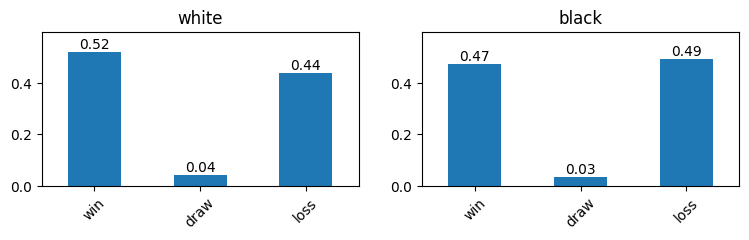

In [11]:
rates_w = df[df["color"] == 1][["win", "draw", "loss"]].mean()
rates_b = df[df["color"] == 0][["win", "draw", "loss"]].mean()

fig, (ax_w, ax_b) = plt.subplots(1, 2, figsize=(9,2))

ax_w = rates_w.plot.bar(ax=ax_w, title="white")
ax_b = rates_b.plot.bar(ax=ax_b, title="black")

for ax, rates in [(ax_w, rates_w), (ax_b, rates_b)]:
    ax.tick_params(axis="x", rotation=45)
    for p in ax.patches:
        text  = f"{p.get_height():.2f}"
        xy    = (p.get_x() + p.get_width() / 2, p.get_height())
        ax.annotate(text, xy, ha="center", va="bottom", )
    ax.set_ylim(0, rates_w.max() * 1.15)

#### `rate_d`

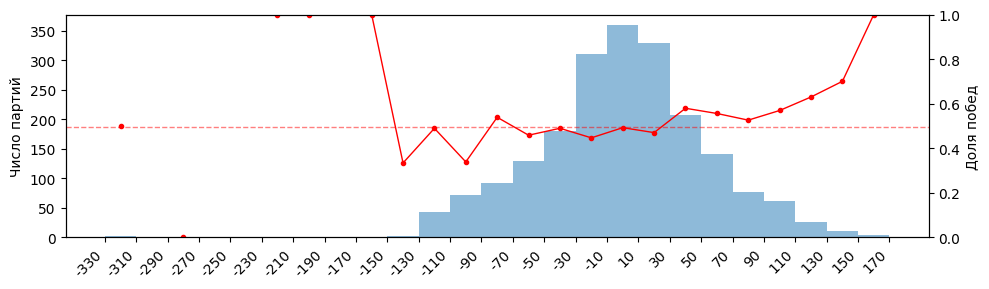

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 3))

# ось 1: количество партий (столбики)

counts, bin_edges, _ = ax1.hist(df["rate_d"], bins=25, alpha=0.5)
ax1.set_xticks(bin_edges)
ax1.set_xticklabels([f"{e:.0f}" for e in bin_edges], rotation=45, ha="right")
ax1.set_ylabel("Число партий")

# ось 2: winrate (линия)

ax2 = ax1.twinx()

bins_cut = pd.cut(df["rate_d"], bins=bin_edges, include_lowest=True)
winrate  = df.groupby(bins_cut, observed=False)["win"].mean()
centers  = (bin_edges[:-1] + bin_edges[1:]) / 2

ax2.plot(centers, winrate.values, color="red", linewidth=1, marker="o", markersize=3)
ax2.axhline(y=df["win"].mean(), color="red", linewidth=1, linestyle="--", alpha=0.5)
ax2.set_ylabel("Доля побед")
ax2.set_ylim(0, 1)

plt.tight_layout()

#### `moves` length

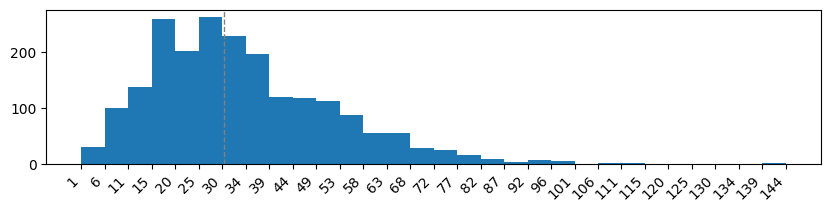

In [13]:
fig, ax = plt.subplots(figsize=(10, 2))

move_counts = df["moves"].apply(len)
counts, bin_edges, patches = ax.hist(move_counts, bins=30)

ax.set_xticks(bin_edges)
ax.set_xticklabels([f"{e:.0f}" for e in bin_edges], rotation=45, ha="right")

# медиана
_ = ax.axvline(x=move_counts.median(), color="grey", linewidth=1, linestyle="--")

#### `moves`

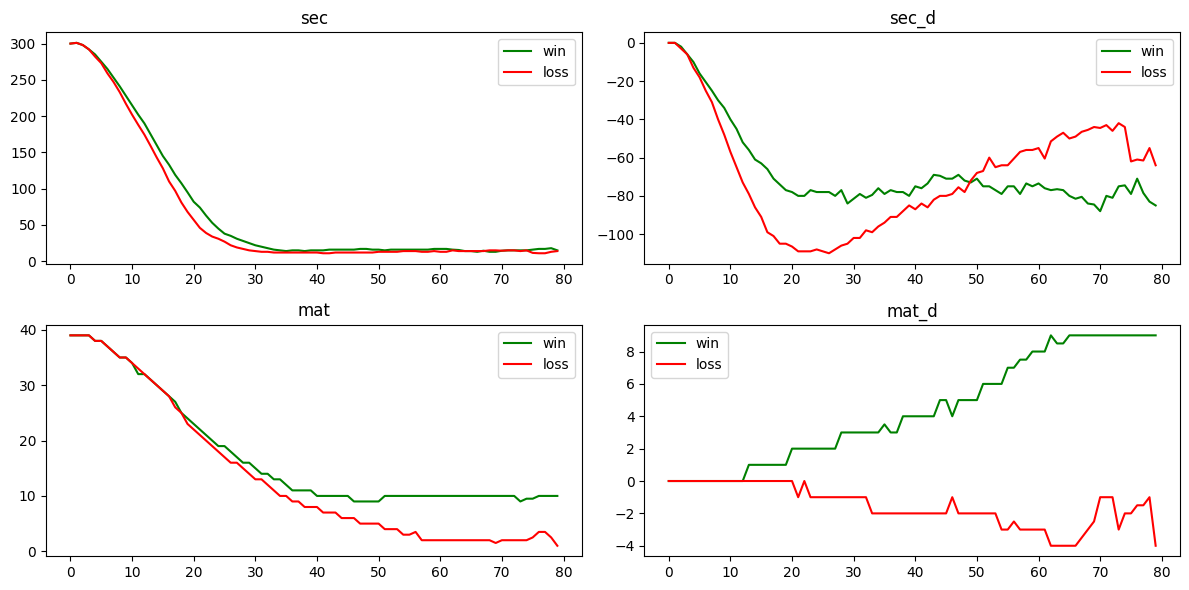

In [14]:
MOVE_N   = 80
FEATURES = [(0, "sec"), (1, "sec_d"), (2, "mat"), (3, "mat_d")]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for ax, (idx, name) in zip(axes.flat, FEATURES):
    for outcome, label, color in [(1, "win", "green"), (0, "loss", "red")]:
        subset = df[df["win"] == outcome]["moves"]
        medians = [
            subset.apply(lambda m, n=n: m[n][idx] if len(m) > n else None).median()
            for n in range(MOVE_N)
        ]
        ax.plot(medians, label=label, color=color)
    ax.set_title(name)
    ax.legend()

plt.tight_layout()

Удивительно, что медианно я всегда отстаю по времени: как в победах, так в поражениях.

## ML

### `df_moves`

In [23]:
rows_ml = []

for game_id, row in df.iterrows():
    for move_n, (sec, sec_d, mat, mat_d) in enumerate(row["moves"]):
        rows_ml.append({
            "game_id":    game_id,
            "date":       row["date"],
            "color":      row["color"],
            "rate_d":     row["rate_d"],
            "rate_d_sq":  0,
            "move_n":     move_n,
            "sec":        sec,
            "sec_d":      sec_d,
            "mat":        mat,
            "mat_d":      mat_d,
            "win":        row["win"],
        })

df_moves = pd.DataFrame(rows_ml)
df_moves["rate_d_sq"] = df_moves["rate_d"] ** 2

df_moves.shape

(68721, 11)

In [24]:
pd.concat([df_moves.head(3), df_moves.tail(3)])

,game_id,date,color,rate_d,rate_d_sq,move_n,sec,sec_d,mat,mat_d,win
0,0,1.0,1,12,144,0,300,0,39,0,0
1,0,1.0,1,12,144,1,302,2,39,0,0
2,0,1.0,1,12,144,2,305,5,39,0,0
68718,2051,0.0,0,-21,441,28,6,-153,16,6,0
68719,2051,0.0,0,-21,441,29,4,-154,11,-7,0
68720,2051,0.0,0,-21,441,30,5,-154,8,-10,0


### `train` / `test`

In [25]:

FEATURES = ["color", "rate_d", "rate_d_sq", "move_n", "sec", "sec_d", "mat", "mat_d"]

games_sorted = df.sort_values("date").index
split_n      = int(len(games_sorted) * 0.85)

train_games  = set(games_sorted[:split_n])
test_games   = set(games_sorted[split_n:])

df_train = df_moves[df_moves["game_id"].isin(train_games)]
df_test  = df_moves[df_moves["game_id"].isin(test_games)]

X_train = df_train[FEATURES]
y_train = df_train["win"].values

X_test  = df_test[FEATURES]
y_test  = df_test["win"].values

w_train = (0.01 + np.log(1 + df_train["date"])).values

print(f"train: {len(train_games)} партий, {len(df_train)} строк")
print(f"test:  {len(test_games)}  партий, {len(df_test)} строк")

train: 1744 партий, 58149 строк
test:  308  партий, 10572 строк


In [67]:
assert set(df_train["game_id"]).isdisjoint(set(df_test["game_id"]))
print("Партии не пересекаются")

Партии не пересекаются


### LogisticRegression

In [58]:
from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import roc_auc_score, accuracy_score

scaler     = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)  # use μ, σ from train

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_sc, y_train, sample_weight=w_train)

acc_lr = accuracy_score(y_test, model_lr.predict(X_test_sc))
auc_lr =  roc_auc_score(y_test, model_lr.predict_proba(X_test_sc)[:, 1])

print(f"LogReg:  accuracy={acc_lr:.3f}  AUC={auc_lr:.3f}")

LogReg:  accuracy=0.677  AUC=0.759


### LightGBM

In [ ]:
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(
    n_estimators  = 1000,
    learning_rate = 0.01,
    max_depth     = 6,
    random_state  = 42,
    verbose       = -1,
)

model_lgb.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)],
)

acc_lgb = accuracy_score(y_test, model_lgb.predict(X_test))
auc_lgb =  roc_auc_score(y_test, model_lgb.predict_proba(X_test)[:, 1])

print(f"LightGBM: accuracy = {acc_lgb:.3f}  AUC = {auc_lgb:.3f}")
print(f"Early stop: {model_lgb.best_iteration_}")

LightGBM: accuracy = 0.692  AUC = 0.766
Early stop: 382


## Метрики

### ROC + Confusion Matrix

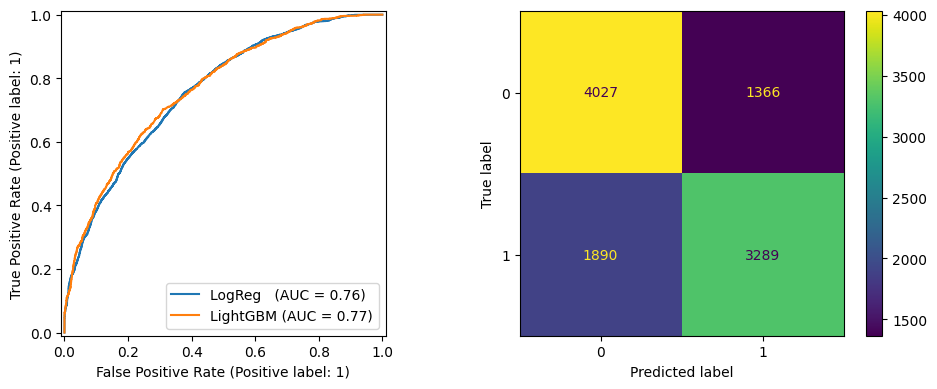

In [76]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

RocCurveDisplay.from_estimator(model_lr,    X_test_sc, y_test, ax=axes[0], name=f"LogReg  ")
RocCurveDisplay.from_estimator(model_lgb, X_test,    y_test, ax=axes[0], name=f"LightGBM")

ConfusionMatrixDisplay.from_estimator(model_lgb, X_test, y_test, ax=axes[1])

plt.tight_layout()

### lgb "gain" importance

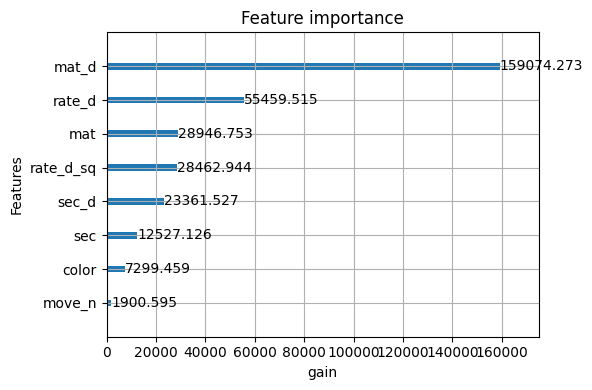

In [77]:
lgb.plot_importance(model_lgb, importance_type="gain", figsize=(6, 4), xlabel="gain")
plt.tight_layout()

# TODO: использовать move_n не как признак, а как уверенность в предсказании

### `move_n` -> AUC

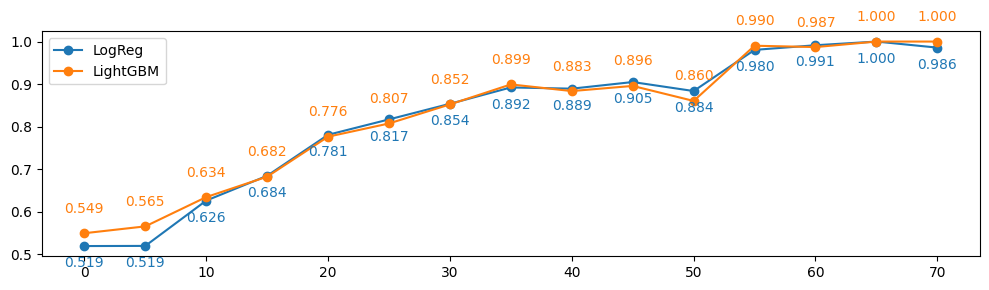

In [75]:
ns, aucs_lr, aucs_lgb = [], [], []

for n in range(0, 80, 5):
    
    mask = df_test["move_n"] == n
    if mask.sum() < 10: continue

    X_n = df_test.loc[mask, FEATURES]
    y_n = df_test.loc[mask, "win"]

    ns.append(n)
    aucs_lr.append(roc_auc_score(y_n, model_lr.predict_proba(scaler.transform(X_n))[:, 1]))
    aucs_lgb.append(roc_auc_score(y_n, model_lgb.predict_proba(X_n)[:, 1]))

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(ns, aucs_lr,  marker="o", label="LogReg")
ax.plot(ns, aucs_lgb, marker="o", label="LightGBM")

ax.legend()

for x, y_lr, y_lgb in zip(ns, aucs_lr, aucs_lgb):
    ax.annotate(f"{y_lr:.3f}",  (x, y_lr),  textcoords="offset points", xytext=(0, -15), ha="center", color="C0")
    ax.annotate(f"{y_lgb:.3f}", (x, y_lgb), textcoords="offset points", xytext=(0, +15), ha="center", color="C1")

plt.tight_layout()